In [ ]:
import jax
# Configure JAX to use GPU if available
try:
    gpu_device = jax.devices('gpu')[0]
    jax.config.update('jax_default_device', gpu_device)
    print("JAX is configured to use GPU.")
except IndexError:
    print("No GPU found. JAX will use CPU.")

In [2]:
!pip install distrax optax --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.7/319.7 kB 12.5 MB/s eta 0:00:00


Output will be saved to: /outputs/ppo_jax_basic
JAX is using: gpu
Default device: cuda:0
Starting PPO training for 5000 updates...
Rollout: 256 actors, 200 steps = 51200 samples
Update: 4 epochs, 400 minibatches of size 128
Update 0, Time: 3.85s, Mean Profit: -1022.2578, Actor Loss: -0.0034, Critic Loss: 1155445.8750, Entropy: 2.2020
Update 50, Time: 0.12s, Mean Profit: -21.2061, Actor Loss: 0.0025, Critic Loss: 4.6110, Entropy: 0.9600
Update 100, Time: 0.12s, Mean Profit: -10.4645, Actor Loss: 0.0008, Critic Loss: 8.1600, Entropy: 1.1689
Update 150, Time: 0.12s, Mean Profit: -4.1540, Actor Loss: 0.0024, Critic Loss: 10.2170, Entropy: 1.2021
Update 200, Time: 0.12s, Mean Profit: -1.0704, Actor Loss: 0.0007, Critic Loss: 7.7563, Entropy: 1.1248
Update 250, Time: 0.12s, Mean Profit: -1.7595, Actor Loss: 0.0009, Critic Loss: 9.9048, Entropy: 1.1599
Update 300, Time: 0.12s, Mean Profit: -1.2096, Actor Loss: 0.0017, Critic Loss: 11.5484, Entropy: 1.1184
Update 350, Time: 0.12s, Mean Profit:

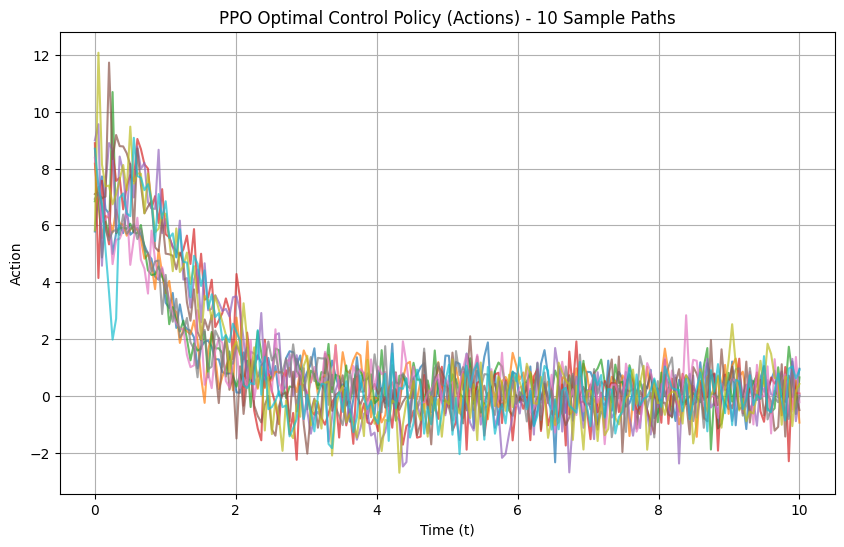

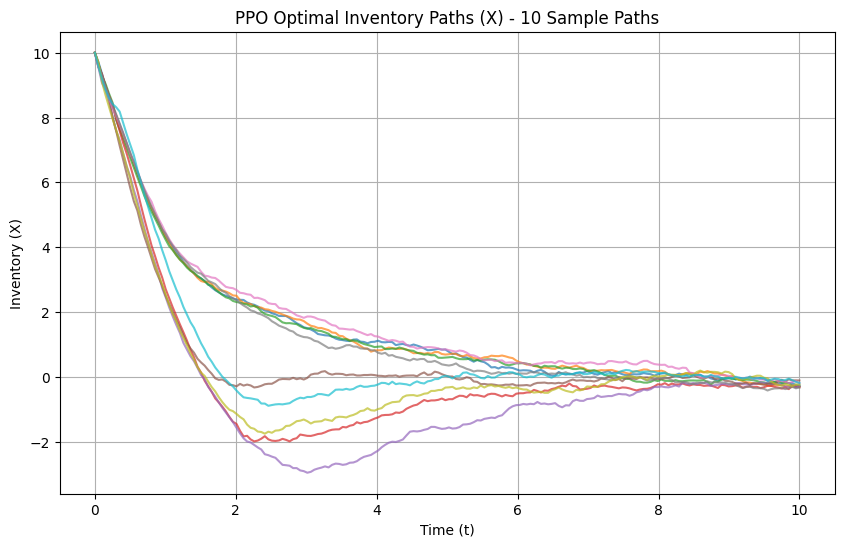

In [12]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
import distrax
from jax import random
from functools import partial
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
import time
import jax.tree_util # Import tree_util

params = {
    "T": 10,
    "SIGMA": 1.0,
    "RHO": 0.5,
    "LAMBDA_L": 1.5,
    "LAMBDA_H": 0.5,
    "KAPPA_L": 0.5,
    "KAPPA_H": 1.5,
    "C_RUNNING": 0.1,
    "C_TERMINAL": 10.0,
    "STATE_BOUNDS": {
        "t": [0.0, 10.0],
        "S": [-5.0, 20.0],
        "X": [-5.0, 20.0],
        "p": [0.0, 1.0],
        "A_l": [0.0, 5.0],
        "A_h": [0.0, 5.0],
    },
    "INITIAL_STATE": {
        "t": 0.0,
        "S": 10.0,
        "X": 10.0,
        "p": 0.5,
        "A_l": 0.0,
        "A_h": 0.0,
    },
}

LOG_STD_MIN = -5.0
LOG_STD_MAX = 2.0

MAX_GRAD_NORM = 1.0


BATCH_SIZE = 256
N = 200


PPO_EPOCHS = 4
MINIBATCH_SIZE = 128
CLIP_EPSILON = 0.2
VF_COEFF = 0.5
ENT_COEFF = 0.01
GAMMA = 1.0


T = float(params["T"])
dt = T / N
RHO = float(params["RHO"])
SIGMA = float(params["SIGMA"])
C_RUNNING = float(params["C_RUNNING"])
C_TERMINAL = float(params["C_TERMINAL"])
LAMBDA_L = float(params["LAMBDA_L"])
LAMBDA_H = float(params["LAMBDA_H"])
KAPPA_L = float(params["KAPPA_L"])
KAPPA_H = float(params["KAPPA_H"])
STATE_BOUNDS = params["STATE_BOUNDS"]
INITIAL_STATE = params["INITIAL_STATE"]

low_bounds = jnp.array([v[0] for v in STATE_BOUNDS.values()], dtype=jnp.float32)
high_bounds = jnp.array([v[1] for v in STATE_BOUNDS.values()], dtype=jnp.float32)


class ActorNetwork(nn.Module):
    hidden_dim: int = 128
    action_dim: int = 1

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(features=self.hidden_dim)(x)
        x = nn.tanh(x)
        mean = nn.Dense(features=self.action_dim)(x)
        log_std = nn.Dense(features=self.action_dim)(x)
        log_std = jnp.clip(log_std, LOG_STD_MIN, LOG_STD_MAX)

        return mean, log_std


class CriticNetwork(nn.Module):
    hidden_dim: int = 128

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(features=self.hidden_dim)(x)
        x = nn.tanh(x)
        value = nn.Dense(features=1)(x)

        return value


@partial(jax.jit, static_argnames=["batch_size"])
def reset_env(key: random.PRNGKey, batch_size: int = BATCH_SIZE):
    initial_values = jnp.array(
        [INITIAL_STATE[k] for k in ["t", "S", "X", "p", "A_l", "A_h"]], dtype=jnp.float32
    )
    state = jnp.tile(initial_values, (batch_size, 1))
    return state


@partial(jax.jit, static_argnames=["batch_size"])
def step_env(
    key: random.PRNGKey, state: jnp.ndarray, actions: jnp.ndarray, batch_size: int = BATCH_SIZE
):
    key, subkey = random.split(key)

    dW_batch = SIGMA * jnp.sqrt(dt) * random.normal(subkey, (batch_size,), dtype=jnp.float32)

    t, S, X, p, A_l, A_h = state.T
    actions = actions.reshape(batch_size)

    impact_diff = LAMBDA_L * (actions + KAPPA_L * A_l) - LAMBDA_H * (actions + KAPPA_H * A_h)

    driftS = -(
        LAMBDA_L * (actions + KAPPA_L * A_l) * p + LAMBDA_H * (actions + KAPPA_H * A_h) * (1.0 - p)
    )

    dS = driftS * dt + dW_batch

    dX = -actions * dt

    dp_hjb = -p * (1.0 - p) * impact_diff * dW_batch

    dA_l = (actions + KAPPA_L * A_l) * dt
    dA_h = (actions + KAPPA_H * A_h) * dt

    t_next = t + dt
    S_next = S + dS
    X_next = X + dX

    p_next = p + dp_hjb
    A_l_next = A_l + dA_l
    A_h_next = A_h + dA_h

    next_state_unclamped = jnp.stack([t_next, S_next, X_next, p_next, A_l_next, A_h_next], axis=1)
    next_state = jnp.clip(next_state_unclamped, low_bounds, high_bounds)

    S_next_batch, X_next_batch = next_state[:, 1], next_state[:, 2]
    instant_profit = ((S_next_batch - RHO * actions) * actions - C_RUNNING * (X_next_batch**2)) * dt

    reward = instant_profit

    done = jnp.zeros(batch_size, dtype=bool)

    return next_state, reward, done


@partial(jax.jit, static_argnames=["actor_apply", "critic_apply", "n_steps", "batch_size"])
def ppo_rollout(
    key: random.PRNGKey,
    actor_params: dict,
    critic_params: dict,
    actor_apply: callable,
    critic_apply: callable,
    initial_state: jnp.ndarray,
    n_steps: int = N,
    batch_size: int = BATCH_SIZE,
):
    def scan_body(carry, _):
        key, current_state = carry
        key, policy_key, env_key = random.split(key, 3)

        mean, log_std = actor_apply({"params": actor_params}, current_state)

        mean = jnp.squeeze(mean, axis=-1)
        log_std = jnp.squeeze(log_std, axis=-1)
        pi = distrax.Normal(loc=mean, scale=jnp.exp(log_std))
        actions = pi.sample(seed=policy_key)
        log_probs = pi.log_prob(actions)

        values = critic_apply({"params": critic_params}, current_state)
        values = jnp.squeeze(values, axis=-1)

        next_state, reward, done = step_env(env_key, current_state, actions, batch_size)

        new_carry = (key, next_state)

        outputs = (current_state, actions, reward, log_probs, values, done)
        return new_carry, outputs

    key, initial_env_key = random.split(key)
    initial_carry = (initial_env_key, initial_state)

    (_, final_state), (states, actions, rewards, log_probs, values, dones) = jax.lax.scan(
        scan_body, initial_carry, None, length=n_steps
    )

    final_value = critic_apply({"params": critic_params}, final_state)
    final_value = jnp.squeeze(final_value, axis=-1)

    S_final, X_final = final_state[:, 1], final_state[:, 2]

    terminal_profit = S_final * X_final - C_TERMINAL * X_final**2

    rewards = rewards.at[-1, :].add(terminal_profit)

    def compute_returns(rewards, final_value, gamma):
        """Computes MC returns backward."""

        def return_scan(carry, reward):
            g = reward + gamma * carry
            return g, g

        _, returns = jax.lax.scan(return_scan, final_value, rewards, reverse=True)
        return returns

    returns = compute_returns(rewards, final_value, GAMMA)

    advantages = returns - values

    advantages = (advantages - jnp.mean(advantages)) / (jnp.std(advantages) + 1e-8)

    num_total_samples = n_steps * batch_size
    states = states.reshape((num_total_samples, -1))
    actions = actions.reshape((num_total_samples,))
    log_probs = log_probs.reshape((num_total_samples,))
    returns = returns.reshape((num_total_samples,))
    advantages = advantages.reshape((num_total_samples,))

    trajectory_data = (states, actions, log_probs, returns, advantages)

    total_profit_batch = jnp.sum(rewards, axis=0)

    return trajectory_data, total_profit_batch


@partial(
    jax.jit,
    static_argnames=[
        "actor_apply",
        "critic_apply",
        "actor_optimizer_update",
        "critic_optimizer_update",
        "num_minibatches",
        "n_steps",
        "batch_size",
    ],
)
def ppo_train_step(
    key: random.PRNGKey,
    actor_params: dict,
    critic_params: dict,
    actor_opt_state: optax.OptState,
    critic_opt_state: optax.OptState,
    actor_apply: callable,
    critic_apply: callable,
    actor_optimizer_update: callable,
    critic_optimizer_update: callable,
    num_minibatches: int,
    n_steps: int = N,
    batch_size: int = BATCH_SIZE,
):
    key, rollout_key, reset_key = random.split(key, 3)
    initial_state = reset_env(reset_key, batch_size)
    trajectory_data, total_profit_batch = ppo_rollout(
        rollout_key,
        actor_params,
        critic_params,
        actor_apply,
        critic_apply,
        initial_state,
        n_steps,
        batch_size,
    )
    states, actions, old_log_probs, returns, advantages = trajectory_data
    num_total_samples = n_steps * batch_size

    def epoch_update(carry, _):
        key, actor_params, critic_params, actor_opt_state, critic_opt_state = carry
        key, perm_key = random.split(key)

        permutation = random.permutation(perm_key, num_total_samples)
        shuffled_states = states[permutation]
        shuffled_actions = actions[permutation]
        shuffled_old_log_probs = old_log_probs[permutation]
        shuffled_returns = returns[permutation]
        shuffled_advantages = advantages[permutation]

        def minibatch_loss(params, batch_info):
            actor_params_mb, critic_params_mb = params
            states_mb, actions_mb, old_log_probs_mb, returns_mb, advantages_mb = batch_info

            mean_new, log_std_new = actor_apply({"params": actor_params_mb}, states_mb)
            mean_new = jnp.squeeze(mean_new, axis=-1)
            log_std_new = jnp.squeeze(log_std_new, axis=-1)
            pi_new = distrax.Normal(loc=mean_new, scale=jnp.exp(log_std_new))
            new_log_probs = pi_new.log_prob(actions_mb)

            ratio = jnp.exp(new_log_probs - old_log_probs_mb)
            surr1 = ratio * advantages_mb
            surr2 = jnp.clip(ratio, 1.0 - CLIP_EPSILON, 1.0 + CLIP_EPSILON) * advantages_mb
            actor_loss = -jnp.mean(jnp.minimum(surr1, surr2))

            values_new = critic_apply({"params": critic_params_mb}, states_mb)
            values_new = jnp.squeeze(values_new, axis=-1)
            critic_loss = jnp.mean((values_new - returns_mb) ** 2)

            entropy = jnp.mean(pi_new.entropy())

            total_loss = actor_loss + VF_COEFF * critic_loss - ENT_COEFF * entropy

            return total_loss, (actor_loss, critic_loss, entropy)

        minibatch_size_per_gpu = MINIBATCH_SIZE

        def process_minibatch(loop_carry, batch_idx):
            key, actor_params_l, critic_params_l, actor_opt_state_l, critic_opt_state_l = loop_carry

            # Use static indices and dynamic_slice instead of NumPy-style indexing
            minibatch_indices = (
                jnp.arange(minibatch_size_per_gpu) + batch_idx * minibatch_size_per_gpu
            )

            # Index using gather operations which are compatible with JIT
            batch_states = jnp.take(shuffled_states, minibatch_indices, axis=0)
            batch_actions = jnp.take(shuffled_actions, minibatch_indices, axis=0)
            batch_old_log_probs = jnp.take(shuffled_old_log_probs, minibatch_indices, axis=0)
            batch_returns = jnp.take(shuffled_returns, minibatch_indices, axis=0)
            batch_advantages = jnp.take(shuffled_advantages, minibatch_indices, axis=0)

            batch = (
                batch_states,
                batch_actions,
                batch_old_log_probs,
                batch_returns,
                batch_advantages,
            )

            params_tuple = (actor_params_l, critic_params_l)
            (total_loss_val, (actor_loss_val, critic_loss_val, entropy_val)), grads = (
                jax.value_and_grad(minibatch_loss, argnums=0, has_aux=True)(params_tuple, batch)
            )

            actor_grads, critic_grads = grads

            actor_updates, new_actor_opt_state = actor_optimizer_update(
                actor_grads, actor_opt_state_l, actor_params_l
            )
            new_actor_params = optax.apply_updates(actor_params_l, actor_updates)

            critic_updates, new_critic_opt_state = critic_optimizer_update(
                critic_grads, critic_opt_state_l, critic_params_l
            )
            new_critic_params = optax.apply_updates(critic_params_l, critic_updates)

            new_loop_carry = (
                key,
                new_actor_params,
                new_critic_params,
                new_actor_opt_state,
                new_critic_opt_state,
            )
            metrics = {
                "total_loss": total_loss_val,
                "actor_loss": actor_loss_val,
                "critic_loss": critic_loss_val,
                "entropy": entropy_val,
            }
            return new_loop_carry, metrics

        final_carry, metrics_PPO = jax.lax.scan(
            process_minibatch,
            (key, actor_params, critic_params, actor_opt_state, critic_opt_state),
            jnp.arange(num_minibatches),
        )

        aggregated_metrics = jax.tree_util.tree_map(jnp.mean, metrics_PPO) # Use jax.tree_util.tree_map

        return final_carry, aggregated_metrics

    initial_epoch_carry = (key, actor_params, critic_params, actor_opt_state, critic_opt_state)
    (
        (
            final_key,
            final_actor_params,
            final_critic_params,
            final_actor_opt_state,
            final_critic_opt_state,
        ),
        epoch_metrics,
    ) = jax.lax.scan(epoch_update, initial_epoch_carry, None, length=PPO_EPOCHS)

    final_metrics = jax.tree_util.tree_map(jnp.mean, epoch_metrics) # Use jax.tree_util.tree_map

    final_metrics["mean_total_profit"] = jnp.mean(total_profit_batch)

    return (
        final_actor_params,
        final_critic_params,
        final_actor_opt_state,
        final_critic_opt_state,
        final_metrics,
    )


def train_policy_ppo_jax(
    num_updates=1000, batch_size=BATCH_SIZE, actor_lr=3e-4, critic_lr=1e-3, seed=42
):
    n_steps = N  # Add this line to fix the undefined variable error
    key = random.PRNGKey(seed)
    actor = ActorNetwork()
    critic = CriticNetwork()

    dummy_state = jnp.zeros((1, 6), dtype=jnp.float32)
    key, actor_key, critic_key = random.split(key, 3)
    actor_params = actor.init(actor_key, dummy_state)["params"]
    critic_params = critic.init(critic_key, dummy_state)["params"]

    actor_optimizer = optax.chain(optax.clip_by_global_norm(MAX_GRAD_NORM), optax.adam(actor_lr))
    critic_optimizer = optax.chain(optax.clip_by_global_norm(MAX_GRAD_NORM), optax.adam(critic_lr))
    actor_opt_state = actor_optimizer.init(actor_params)
    critic_opt_state = critic_optimizer.init(critic_params)

    actor_apply_fn = actor.apply
    critic_apply_fn = critic.apply
    actor_optimizer_update_fn = actor_optimizer.update
    critic_optimizer_update_fn = critic_optimizer.update

    num_total_samples = n_steps * batch_size
    assert num_total_samples % MINIBATCH_SIZE == 0, (
        "Total samples must be divisible by minibatch size"
    )
    num_minibatches = num_total_samples // MINIBATCH_SIZE

    jitted_ppo_train_step = partial(
        ppo_train_step,
        actor_apply=actor_apply_fn,
        critic_apply=critic_apply_fn,
        actor_optimizer_update=actor_optimizer_update_fn,
        critic_optimizer_update=critic_optimizer_update_fn,
        num_minibatches=num_minibatches,
        n_steps=N,
        batch_size=batch_size,
    )

    print(f"Starting PPO training for {num_updates} updates...")
    print(f"Rollout: {batch_size} actors, {n_steps} steps = {num_total_samples} samples")
    print(f"Update: {PPO_EPOCHS} epochs, {num_minibatches} minibatches of size {MINIBATCH_SIZE}")

    for update_num in range(num_updates):
        start_time = time.time()
        key, step_key = random.split(key)
        actor_params, critic_params, actor_opt_state, critic_opt_state, metrics = (
            jitted_ppo_train_step(
                step_key, actor_params, critic_params, actor_opt_state, critic_opt_state
            )
        )
        end_time = time.time()

        if update_num % 50 == 0:
            print(
                f"Update {update_num}, Time: {end_time - start_time:.2f}s, "
                f"Mean Profit: {metrics['mean_total_profit']:.4f}, "
                f"Actor Loss: {metrics['actor_loss']:.4f}, "
                f"Critic Loss: {metrics['critic_loss']:.4f}, "
                f"Entropy: {metrics['entropy']:.4f}"
            )

        if jnp.isnan(metrics["mean_total_profit"]) or jnp.isinf(metrics["mean_total_profit"]):
            print(f"NaN or Inf detected in profit at update {update_num}. Stopping.")
            break
        if jnp.isnan(metrics["actor_loss"]) or jnp.isinf(metrics["actor_loss"]):
            print(f"NaN or Inf detected in actor loss at update {update_num}. Stopping.")
            break

    print("Training finished.")

    return actor_params, actor_apply_fn


def save_policy_ppo_jax(actor_params, path):
    os.makedirs(path, exist_ok=True)
    filepath = os.path.join(path, "ppo_actor_params.pkl")
    numpy_params = jax.tree_util.tree_map(np.array, actor_params) # Use jax.tree_util.tree_map
    with open(filepath, "wb") as f:
        pickle.dump(numpy_params, f)
    print(f"PPO Actor parameters saved to {filepath}")


@partial(jax.jit, static_argnames=["actor_apply", "n_steps", "batch_size"])
def simulate_actor_policy(
    key: random.PRNGKey,
    actor_params: dict,
    actor_apply: callable,
    initial_state: jnp.ndarray,
    n_steps: int = N,
    batch_size: int = 1,
):
    """Simplified rollout just for simulation using only the actor."""

    def scan_body(carry, _):
        key, current_state = carry
        key, policy_key, env_key = random.split(key, 3)

        mean, log_std = actor_apply({"params": actor_params}, current_state)
        mean = jnp.squeeze(mean, axis=-1)
        log_std = jnp.squeeze(log_std, axis=-1)  # Squeeze log_std as well

        pi = distrax.Normal(loc=mean, scale=jnp.exp(log_std))
        actions = pi.sample(seed=policy_key)

        next_state, reward, done = step_env(env_key, current_state, actions, batch_size)
        new_carry = (key, next_state)
        outputs = (current_state, actions, reward)
        return new_carry, outputs

    key, initial_env_key = random.split(key)
    initial_carry = (initial_env_key, initial_state)
    (_, final_state), (states, actions, rewards) = jax.lax.scan(
        scan_body, initial_carry, None, length=n_steps
    )
    return states, actions, rewards, final_state


def simulate_and_plot_ppo(key, actor_params, actor_apply, num_paths=10, n_steps=N): # Removed save_path
    key, reset_key, sim_key = random.split(key, 3)
    initial_state_batch = reset_env(reset_key, batch_size=num_paths)

    print(f"Simulating {num_paths} paths...")
    states, actions, _, _ = simulate_actor_policy(
        sim_key, actor_params, actor_apply, initial_state_batch, n_steps, num_paths
    )

    actions_np = np.array(actions)
    states_np = np.array(states)
    time_steps = np.linspace(0, T, n_steps)

    print("Plotting results...")
    plt.figure(figsize=(10, 6))
    for i in range(num_paths):
        plt.plot(time_steps, actions_np[:, i], alpha=0.7)
    plt.title(f"PPO Optimal Control Policy (Actions) - {num_paths} Sample Paths")
    plt.xlabel("Time (t)")
    plt.ylabel("Action")
    plt.grid(True)
    plt.show() # Show plot directly

    plt.figure(figsize=(10, 6))
    for i in range(num_paths):
        plt.plot(time_steps, states_np[:, i, 2], alpha=0.7) # Index 2 corresponds to X (Inventory)
    plt.title(f"PPO Optimal Inventory Paths (X) - {num_paths} Sample Paths")
    plt.xlabel("Time (t)")
    plt.ylabel("Inventory (X)")
    plt.grid(True)
    plt.show() # Show plot directly


if __name__ == "__main__":
    try:
        script_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        script_dir = os.path.abspath(".")

    save_dir = os.path.abspath(os.path.join(script_dir, "../../../outputs/ppo_jax_basic"))
    print(f"Output will be saved to: {save_dir}")
    os.makedirs(save_dir, exist_ok=True)

    # Check and print the JAX device being used
    default_device = jax.default_backend()
    print(f"JAX is using: {default_device}")
    try:
        print(f"Default device: {jax.devices()[0]}")
    except IndexError:
        print("No JAX devices found.")


    main_key = random.PRNGKey(42)
    train_key, plot_key = random.split(main_key)

    trained_actor_params, actor_apply_fn = train_policy_ppo_jax(
        num_updates=5000,
        batch_size=BATCH_SIZE,
        actor_lr=3e-4,
        critic_lr=1e-3,
        seed=int(train_key[0]),
    )

    if trained_actor_params:
        # Save policy (optional, keep if needed elsewhere)
        save_policy_ppo_jax(trained_actor_params, save_dir)

        # Simulate and plot directly in the notebook
        simulate_and_plot_ppo(
            plot_key, trained_actor_params, actor_apply_fn, num_paths=10
        ) # Removed save_path argument


In [13]:
from IPython.display import FileLink

# Generate a download link for the file
file_path = '/outputs/ppo_jax_basic/ppo_actor_params.pkl'
FileLink(file_path)

/outputs/ppo_jax_basic/ppo_actor_params.pkl